In [1]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.nn.functional import interpolate

from datasets import load_dataset
from inpaintingStart import *
import argparse

from PIL import Image
import gradio as gr
from imagenet_en_cn import IMAGENET_1K_CLASSES
from omegaconf import OmegaConf

import torch
from transformers import T5EncoderModel, AutoTokenizer

from pixelflow.scheduling_pixelflow import PixelFlowScheduler
from pixelflow.pipeline_pixelflow import PixelFlowPipeline
from pixelflow.utils import config as config_utils
from pixelflow.utils.misc import seed_everything

from sampler import PixelFlowPipeline2

import matplotlib.pyplot as plt
import imageio
import math
import copy
from pathlib import Path
from einops import rearrange
# ds = load_dataset("ILSVRC/imagenet-1k")

/home/ruy45/anaconda3/envs/pixelflow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '~/dataset/imageNet256/ILSVRC/Data/CLS-LOC/train/'

def center_crop_arr(pil_image, image_size):
    while min(*pil_image.size) >= 2 * image_size:
        pil_image = pil_image.resize(
            tuple(x // 2 for x in pil_image.size), resample=Image.BOX
        )

    scale = image_size / min(*pil_image.size)
    pil_image = pil_image.resize(
        tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
    )

    arr = np.array(pil_image)
    crop_y = (arr.shape[0] - image_size) // 2
    crop_x = (arr.shape[1] - image_size) // 2
    return Image.fromarray(arr[crop_y: crop_y + image_size, crop_x: crop_x + image_size])

transform = transforms.Compose([
    transforms.Lambda(lambda pil_image: center_crop_arr(pil_image, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)])
dataset = ImageFolder(data_dir, transform=transform)

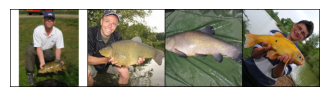

In [3]:
loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False, num_workers=4)
imgs, labels = next(iter(loader))      # imgs: [B,3,256,256] in [-1,1]
imgs_vis = (imgs * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(imgs_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

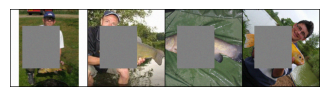

In [4]:
sigma_n =0.05
A_opr = op = get_operator(
        "inpainting",
        mask_type='box',
        mask_len_range=(80, 160),
        mask_prob_range=None,
        resolution=256,
        device='cpu',
        sigma=sigma_n,
    )
y = A_opr.measure(imgs)
y_vis = (y * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [58]:
def sample_block_noise(scheduler, bs, ch, height, width, eps=1e-6):
        gamma = scheduler.gamma
        dist = torch.distributions.multivariate_normal.MultivariateNormal(torch.zeros(4), torch.eye(4) * (1 - gamma) + torch.ones(4, 4) * gamma + eps * torch.eye(4))
        block_number = bs * ch * (height // 2) * (width // 2)
        noise = torch.stack([dist.sample() for _ in range(block_number)]) # [block number, 4]
        noise = rearrange(noise, '(b c h w) (p q) -> b c (h p) (w q)',b=bs,c=ch,h=height//2,w=width//2,p=2,q=2)
        return noise
def down2_bilinear(x):
    H, W = x.shape[-2], x.shape[-1]
    return F.interpolate(x, size=(H // 2, W // 2), mode="bilinear", align_corners=False)
def get_xstart_xend_pyramid(x, stage_idx, num_stages, scheduler, T):
    start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
    x_end = x
    if T == start_t:
        print("smooth Transition at stage", stage_idx, T.item())
        height, width = height * 2, width * 2
        latents = F.interpolate(latents, size=(height, width), mode='nearest')
        original_start_t = scheduler.original_start_t[stage_idx]
        gamma = scheduler.gamma
        alpha = 1 / (math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t)
        beta = alpha * (1 - original_start_t) / math.sqrt(- gamma)

        # bs, ch, height, width = latents.shape
        noise = sample_block_noise(*latents.shape)
        noise = noise.to(device=latents.device, dtype=latents.dtype)
        latents = alpha * latents + beta * noise
        return latents
    for _ in range(num_stages-stage_idx-1):
        x_end = down2_bilinear(x_end)
    noise = torch.randn_like(x_end, device=x.device)
    x_end = end_t * x_end + (1.0 - end_t) * noise
    x_start = x
    for _ in range(num_stages-stage_idx):
        x_start = down2_bilinear(x_start)
    x_start = F.interpolate(x_start, size=x_end.shape[-2:], mode="nearest")
    x_start = start_t * x_start + (1.0 - start_t) * noise
    tau = (scheduler.t_window_per_stage[stage_idx][int(T.item())].flatten() - start_t)/(end_t -start_t)
    tau = tau.to(x.device)
    xt = tau*x_end + (1- tau)*x_start
    return xt

In [59]:
def get_xstart_xend_pyramid(x, stage_idx, num_stages, scheduler, T):
    start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
    x_end = x.clone().detach()
    for _ in range(num_stages-stage_idx-1):
        x_end = down2_bilinear(x_end)
    noise = torch.randn_like(x_end, device=x.device)
    x_end = end_t * x_end + (1.0 - end_t) * noise
    if stage_idx>0:
        print("smooth Transition at stage", stage_idx, T.item())
        x_start = copy.deepcopy(x)
        for _ in range(num_stages-stage_idx):
            x_start = down2_bilinear(x_start)
        height, width = x_start.shape[-2], x_start.shape[-1]
        height, width = height * 2, width * 2
        x_start = F.interpolate(x_start, size=(height, width), mode='nearest')
        original_start_t = scheduler.original_start_t[stage_idx]
        gamma = scheduler.gamma
        alpha = 1 / (math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t)
        beta = alpha * (1 - original_start_t) / math.sqrt(- gamma)
        print(x_start.shape, alpha, beta)
        # bs, ch, height, width = latents.shape
        noise = sample_block_noise(scheduler,*x_start.shape)
        noise = noise.to(device=x_start.device, dtype=x_start.dtype)
        x_start = alpha * x_start + beta * noise
    else:
        x_start = copy.deepcopy(noise)
        print(x_start.shape)
    # for _ in range(num_stages-stage_idx):
    #     x_start = down2_bilinear(x_start)
    # x_start = F.interpolate(x_start, size=x_end.shape[-2:], mode="nearest")
    # x_start = start_t * x_start + (1.0 - start_t) * noise
    tau = (scheduler.t_window_per_stage[stage_idx][int(T.item())].flatten() - start_t)/(end_t -start_t)
    tau = tau.to(x.device)
    xt = tau*x_end + (1- tau)*x_start
    return xt

In [33]:
def get_xstart_xend_pyramid(x, stage_idx, num_stages, scheduler, T):
    x_end = x
    for _ in range(num_stages-stage_idx-1):
        x_end = down2_bilinear(x_end)
    noise = torch.randn_like(x_end, device=x.device)
    normalized_T = T/1000
    return normalized_T*x_end + (1-normalized_T)*noise

In [38]:
@torch.no_grad()
def langevin_update(
    x: torch.Tensor,
    operator,
    y: torch.Tensor,
    x0hat: torch.Tensor,      
    sigma_n: float,          
    T: float, #inference_step           
    step_size: float, 
    device
):
    x = x.to(device)
    y = y.to(device)
    """
    One step overdamped Langevin for p(x) ∝ exp(-L(x)).
    L(x) = 1/(2σ_n^2)||Hx-y||^2 + 1/(2ν_t^2)||x-x1hat||^2
    """
    def nu_t(T):
        nt = T/1000
        return 1-nt
        # return (1 - nt)/math.sqrt(nt**2 + (1 - nt)**2)
    # ∇||Hx - y||^2  (operator.gradient 内部会用 autograd)
    with torch.enable_grad():
        x = x.detach().requires_grad_(True)
        grad_data_sq = operator.gradient(x, y)
        # grad_data_sq = torch.autograd.grad(((operator.measure(x) -y)**2/(2*sigma_n**2)).sum(), x)[0]
        grad_loss = (x-x0hat)**2 / (2*nu_t(T)**2 + 1e-4)
        grad_prior = torch.autograd.grad(grad_loss.sum(), x)[0]
    grad_data = grad_data_sq / (2.0 * (sigma_n ** 2))  # => (1/σ_n^2) H^T(Hx-y)
    # print(grad_data_sq.norm(), grad_prior.norm())
    # grad_data = grad_data_sq / (2.0 * (sigma_n ** 2)) 

    # ∇ 1/(2ν_t^2)||x - x0hat||^2
    # grad_prior = (x - x0hat) / (nu_t(T) ** 2 + 1e-4)

    grad_L = grad_data + grad_prior

    eps = torch.randn_like(x)
    x_new = x - step_size * grad_L + math.sqrt(2.0 * step_size) * eps
    return x_new

def langevin_sample(
    x_init, operator, y, x0hat,
    sigma_n, T,
    step_size=1e-4, num_steps=50,
    device = 'cpu',
    proj = False
):
    if proj:
        o_M = operator.mask.to(device)
    else:
        o_M = torch.zeros_like(y, device=device)
    x = x_init.clone().detach()
    for _ in range(num_steps):
        # x = langevin_update(x, operator, y, x0hat, sigma_n, T, step_size, device)
        x = (1-o_M)*langevin_update(x, operator, y, x0hat, sigma_n, T, step_size, device) + o_M*y
        if torch.isnan(x).any():
            break
    return x.detach()

def get_lr(ratio, lr_base = 1e-4, lr_min_ratio = 0.01):
    p = 1
    multiplier = (1 ** (1 / p) + ratio * (lr_min_ratio ** (1 / p) - 1 ** (1 / p))) ** p
    return multiplier * lr_base


In [7]:
num_stages = 4 # config.scheduler.num_stages
inference_each_step = 10
class_label = 1000
NUM_EXAMPLES = 16
resolution = 256
num_Langevin = 100
lr_base = 1e-4
lr_min_ratio = 1e-2
sigma_n =0.05
proj = True
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
output_dir = './pretrained_models/c2img'
A_opr = get_operator("inpainting", mask_type='box', mask_len_range=(80, 160), mask_prob_range=None, resolution=resolution, device=device, sigma=sigma_n)
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
config = OmegaConf.load(f"{output_dir}/config.yaml")
model = config_utils.instantiate_from_config(config.model).to(device)
print(f"Num of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
ckpt = torch.load(f"{output_dir}/model.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt, strict=True)
model.eval()
text_encoder = None
tokenizer = None
scheduler = PixelFlowScheduler(config.scheduler.num_train_timesteps, num_stages=config.scheduler.num_stages, gamma=-1/3)
scheduler_copy = copy.deepcopy(scheduler)
sampler_pipeline = PixelFlowPipeline2(scheduler_copy,model,text_encoder=text_encoder,tokenizer=tokenizer, max_token_length=512,)

Starting Initialization...
Num of parameters: 676611120


In [8]:
# for stage_idx in range(config.scheduler.num_stages):
#     corrected_stage_idx = config.scheduler.num_stages - stage_idx - 1
#     end_height, end_width = resolution // (2 ** stage_idx), resolution // (2 ** stage_idx)

#     ################ build model input ################
#     start_t, end_t = scheduler.start_t[corrected_stage_idx], scheduler.end_t[corrected_stage_idx]
#     print(f"Stage {stage_idx}: start_t={start_t}, end_t={end_t}, end_height={end_height}, end_width={end_width} ")


In [9]:
# def get_xt_with_x0_1_hat(xs_hat, xe_hat, t, scheduler, stage_idx):
#     """
#         get xt with x0_hat and x0_y
#     """
#     corrected_stage_idx = config.scheduler.num_stages - stage_idx - 1
#     start_t, end_t = scheduler.start_t[corrected_stage_idx], noise_scheduler_copy.end_t[corrected_stage_idx]
#     xt = t_select.float() * xe_hat + (1.0 - t_select.float()) * xs_hat
#     return xt

In [42]:
idx = torch.randperm(len(dataset))[:NUM_EXAMPLES]
gt = torch.stack([dataset[i][0] for i in idx], dim=0) 
labels = [dataset[i][1] for i in idx]
y = A_opr.measure(gt).to(device)

In [60]:
inference_each_step = 10
for stage_idx in range(num_stages):
    scheduler.set_timesteps(inference_each_step, stage_idx, device=device, shift=1.0)
    Timesteps = scheduler.Timesteps
    start_t = scheduler.Timesteps[0]
    for idx, T in enumerate(Timesteps): 
        if stage_idx == 0 and T == Timesteps[0]:
            print("No xt")
            xt = None
        else:
            xt = get_xstart_xend_pyramid(x0_hat_last, stage_idx, num_stages, scheduler, T)
            print(f"xt obtained at stage {stage_idx}, step {idx}, Inference step {T.item()}")
        with torch.autocast("cuda", dtype=torch.bfloat16), torch.no_grad():
            # x0_hat = sampler_pipeline(prompt=[class_label] * NUM_EXAMPLES,
            #                             height=resolution,
            #                             width=resolution,
            #                             num_inference_steps=2,
            #                             guidance_scale=0.0,
            #                             num_images_per_prompt=1,
            #                             device=device,
            #                             shift=1.0,
            #                             use_ode_dopri5=False,
            #                             xt = xt,          
            #                             start_stage = stage_idx,             
            #                             start_T = T,          
            #                             normalized_x0_hat = False)
            x0_hat = sampler_pipeline(prompt=labels,
                                        height=resolution,
                                        width=resolution,
                                        num_inference_steps=2,
                                        guidance_scale=1.0,
                                        num_images_per_prompt=1,
                                        device=device,
                                        shift=1.0,
                                        use_ode_dopri5=False,
                                        xt = xt,          
                                        start_stage = stage_idx,             
                                        start_T = T,          
                                        normalized_x0_hat = False)
        # print(idx)
        if idx>0 or stage_idx>0:
            test_img = (x0_hat[0] / 2 + 0.5).clamp(0, 1)
            test_img = test_img.cpu().permute(1,2, 0).float().numpy()
            test_img = Image.fromarray((test_img * 255).round().astype("uint8"))
            test_img.save(f"{output_dir}/test_img_{stage_idx}_{idx}_{T}.png")

            # test_img = (xt[0] / 2 + 0.5).clamp(0, 1)
            # test_img = test_img.cpu().permute(1,2, 0).float().numpy()
            # test_img = Image.fromarray((test_img * 255).round().astype("uint8"))
            # test_img.save(f"{output_dir}/xt_{stage_idx}_{idx}.png")

        ratio = T/1000
        lr = get_lr(ratio, lr_base, lr_min_ratio)
        x0_hat_last = copy.deepcopy(x0_hat)
        x0_hat_last = langevin_sample(x0_hat_last, A_opr, y, x0_hat, sigma_n, T, step_size=lr, num_steps=10, device = device, proj = proj)
        if idx>0 or stage_idx>0:
            test_img = (x0_hat_last[0] / 2 + 0.5).clamp(0, 1)
            test_img = test_img.cpu().permute(1,2, 0).float().numpy()
            test_img = Image.fromarray((test_img * 255).round().astype("uint8"))
            test_img.save(f"{output_dir}/test_imgAL_{stage_idx}_{idx}_{T}.png")
            
    
samples = (x0_hat / 2 + 0.5).clamp(0, 1)
samples = samples.cpu().permute(0, 2, 3, 1).float().numpy()
samples = (samples * 255).round().astype("uint8")
samples = [Image.fromarray(sample) for sample in samples]

# sampler_pipeline(prompt=[class_label] * NUM_EXAMPLES,
#     height=resolution,
#     width=resolution,
#     start_x = prev,
#     start_t = start_t,
#     start_stage = stage_idx,
#     num_inference_steps= 2,
#     guidance_scale=0,
#     device=device,
#     shift=1,
#     use_ode_dopri5=False,
#     normalized_x0_hat = False)


No xt
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 1, Inference step 19.425
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 2, Inference step 38.85
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 3, Inference step 58.275000000000006
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 4, Inference step 77.7
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 5, Inference step 97.12500000000001
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 6, Inference step 116.55000000000001
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 7, Inference step 135.975
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 8, Inference step 155.4
torch.Size([16, 3, 32, 32])
xt obtained at stage 0, step 9, Inference step 174.825
smooth Transition at stage 1 175.0
torch.Size([16, 3, 64, 64]) 0.5714285714285714 0.7423074889580903
xt obtained at stage 1, step 0, Inference step 175.0
smooth Transition at stage 1 202.861
torch.Size([16, 3, 64, 64]) 0.57

In [ ]:
# To do Jump point
# 1. After getting xt|y at the end point, smooth jump at set it to be the next start point
# 2. Or try directly set down sample x0|y wo upsampling

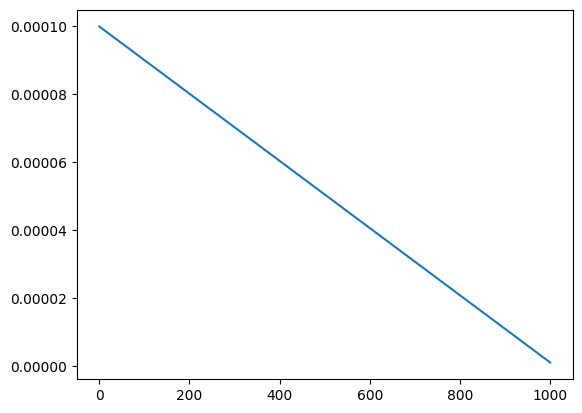

In [97]:
T = np.linspace(0, 1000, num=5000)
ratio = T/1000
lr = get_lr(ratio, lr_base, lr_min_ratio)
plt.plot(T, lr)

In [12]:
gt = (gt / 2 + 0.5).clamp(0, 1)
gt = gt.cpu().permute(0, 2, 3, 1).float().numpy()
gt = (gt * 255).round().astype("uint8")
gt = [Image.fromarray(i) for i in gt]

y = (y / 2 + 0.5).clamp(0, 1)
y = y.cpu().permute(0, 2, 3, 1).float().numpy()
y = (y * 255).round().astype("uint8")
y = [Image.fromarray(i) for i in y]

for idx, sample in enumerate(samples):
    sample.save(f"{output_dir}/sample_{idx}.png")
for idx, sample in enumerate(gt):
    sample.save(f"{output_dir}/gt_{idx}.png")
for idx, sample in enumerate(y):
    sample.save(f"{output_dir}/y_{idx}.png")

In [ ]:
# def inferChangeInit(use_ode_dopri5, noise_shift, cfg_scale, class_label, seed, num_steps_per_stage:list):
#     seed_everything(seed)
#     with torch.autocast("cuda", dtype=torch.bfloat16), torch.no_grad():
#         samples = sampler_pipeline(
#             prompt=[class_label] * NUM_EXAMPLES,
#             height=resolution,
#             width=resolution,
#             num_inference_steps= num_steps_per_stage,
#             guidance_scale=cfg_scale,         # The guidance for the first frame, set it to 7 for 384p variant
#             device=device,
#             shift=noise_shift,
#             normalized_x0_hat = True
#         )
#     samples = (samples * 255).round().astype("uint8")
#     samples = [Image.fromarray(sample) for sample in samples]
#     return samples
# samples = inferChangeInit(use_ode_dopri5=False, noise_shift=1.0, cfg_scale=0.0, class_label=10, seed=0, num_steps_per_stage = [10 for _ in range(4)])
# for idx, sample in enumerate(samples):
#     sample.save(f"{output_dir}/sample_{idx}.png")

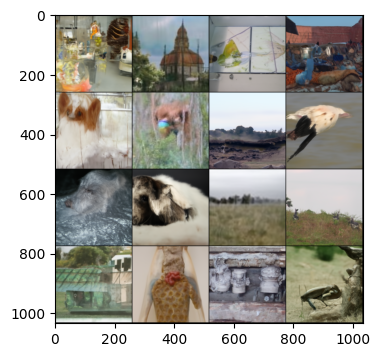

In [87]:
xt_vis = (x0_hat.float() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))

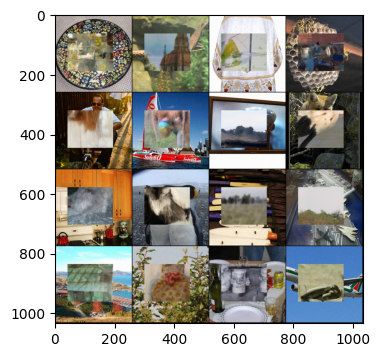

In [89]:
o_M = A_opr.mask.to(device)
x_check = o_M * y + (1 - o_M) * x0_hat
xt_vis = (x_check * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))

In [86]:
x0_hat.min(), x0_hat.max()

(tensor(-1.0078, device='cuda:1', dtype=torch.bfloat16),
 tensor(1.0078, device='cuda:1', dtype=torch.bfloat16))

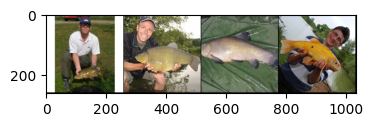

In [19]:
imgs, labels = next(iter(loader)) 
xt_vis = (imgs * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))

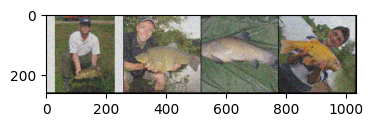

In [20]:
stage = 1
T = torch.Tensor([250])
xt = get_xstart_xend_pyramid(imgs.to(device), 3, 4, scheduler, 719.0)
xt_vis = (xt * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))

In [ ]:

x0_hat = sampler_pipeline(prompt=[class_label] * 4,
                                        height=resolution,
                                        width=resolution,
                                        num_inference_steps=10,
                                        guidance_scale=0.0,
                                        num_images_per_prompt=1,
                                        device=device,
                                        shift=1.0,
                                        use_ode_dopri5=False,
                                        xt = xt,          
                                        start_stage = stage,             
                                        start_T = T,          
                                        normalized_x0_hat = False,
                                        )
xt_vis = (x0_hat * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))


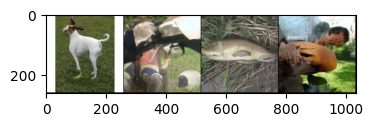

In [18]:

x0_hat = sampler_pipeline(prompt=[class_label] * 4,
                                        height=resolution,
                                        width=resolution,
                                        num_inference_steps=10,
                                        guidance_scale=0.0,
                                        num_images_per_prompt=1,
                                        device=device,
                                        shift=1.0,
                                        use_ode_dopri5=False,
                                        xt = xt,          
                                        start_stage = stage,             
                                        start_T = T,          
                                        normalized_x0_hat = False,
                                        )
xt_vis = (x0_hat * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(xt_vis.cpu(), nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))


In [ ]:
# check with xt trajectory with ode